# Heat Maps for Poster

In [81]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
import cmocean.cm as cm
import datetime as datetime
#
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
path_sim = '/ocean/vvalenzuela/MOAD/analysis-vicente/Ocean_Parcels/PBDE_simulations/long_term_simulation.nc'
data_full = xr.open_dataset(path_sim)
#
data = data_full.isel(obs = slice(None, 4380))

In [48]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [50]:
def particles_amount(
    lons, lats, mask=mask, num_lon=200, num_lat=200
):
    # Convert to numpy (avoids xarray overhead inside histogram)
    nav_lon = mask['nav_lon'].values
    nav_lat = mask['nav_lat'].values

    # Bin edges
    lon_edges = np.linspace(nav_lon.min(), nav_lon.max(), num_lon + 1)
    lat_edges = np.linspace(nav_lat.min(), nav_lat.max(), num_lat + 1)

    # Bin centers
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    # Histogram for ALL particles
    counts, xedges, yedges = np.histogram2d(
        lons, lats,
        bins=[lon_edges, lat_edges]
    )

    df = pd.DataFrame(
        counts.T,  # lat rows, lon cols
        index=lat_centers,
        columns=lon_centers
    )

    # 🔥 Build grid indices MUCH faster
    Xcenters, Ycenters = np.meshgrid(lon_centers, lat_centers)

    # Flatten once
    flat_lon = Xcenters.ravel()
    flat_lat = Ycenters.ravel()

    ii_sed = np.zeros(flat_lon.size, dtype=int)
    jj_sed = np.zeros(flat_lon.size, dtype=int)

    for k in range(flat_lon.size):
        jj, ii = finder2(flat_lat[k], flat_lon[k], mask)
        ii_sed[k] = ii
        jj_sed[k] = jj

    ii_sed = ii_sed.reshape(Xcenters.shape)
    jj_sed = jj_sed.reshape(Ycenters.shape)

    grid_indices = (ii_sed, jj_sed)

    raw_hist = (counts, xedges, yedges)

    return df, raw_hist, grid_indices


In [ ]:
data.time[0,1080].values
# 
# 1080
# 348
# 156
# 72

numpy.datetime64('2007-04-01T00:30:00.000000000')

In [72]:
idx_week1 = int((7 * 86400) / 900)
idx_week2 = int((14 * 86400) / 900)
idx_month1 = int((30 * 86400) / 900)
idx_month3 = int((90 * 86400) / 900)
# 12 months
data_week1 = data.isel(trajectory=slice(0, idx_week1), obs = slice(0, 6*12))
data_week2 = data.isel(trajectory=slice(0, idx_week2), obs = slice(0, 13*12))
data_month1 = data.isel(trajectory=slice(0, idx_month1), obs = slice(0, 30*12))
data_month3 = data.isel(trajectory=slice(0, idx_month3), obs = slice(0, 90*12))

In [79]:
amount1, _, grid_ij1 = particles_amount(data_week1['lon'].values.flatten(), data_week1['lat'].values.flatten())
amount2, _, grid_ij2 = particles_amount(data_week2['lon'].values.flatten(), data_week2['lat'].values.flatten())
amount3, _, grid_ij3 = particles_amount(data_month1['lon'].values.flatten(), data_month1['lat'].values.flatten())
amount4, _, grid_ij4 = particles_amount(data_month3['lon'].values.flatten(), data_month3['lat'].values.flatten())

In [103]:
levels_water = np.linspace(0,500,10)
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')

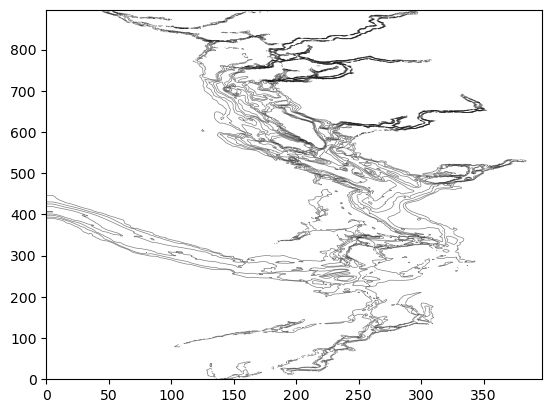

In [104]:
plt.contour(bathy.x, bathy.y, bathy['Bathymetry'], levels = levels_water, colors='black', alpha = .5
           ,linewidths=0.5, linestyles='solid')

In [151]:
levels = [10e0, 10e1, 10e2, 10e3, 10e4, 10e5, 10e6]
lat_source = 49.195045
lon_source = -123.301956
y_source, x_source = finder2(lat_source, lon_source)

/tmp/ipykernel_341069/3052686591.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  caca1 = ax[0].pcolormesh(grid_ij1[0], grid_ij1[1], amount1,
/tmp/ipykernel_341069/3052686591.py:24: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  caca2 = ax[1].pcolormesh(grid_ij2[0], grid_ij2[1], amount2,
/tmp/ipykernel_341069/3052686591.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  caca

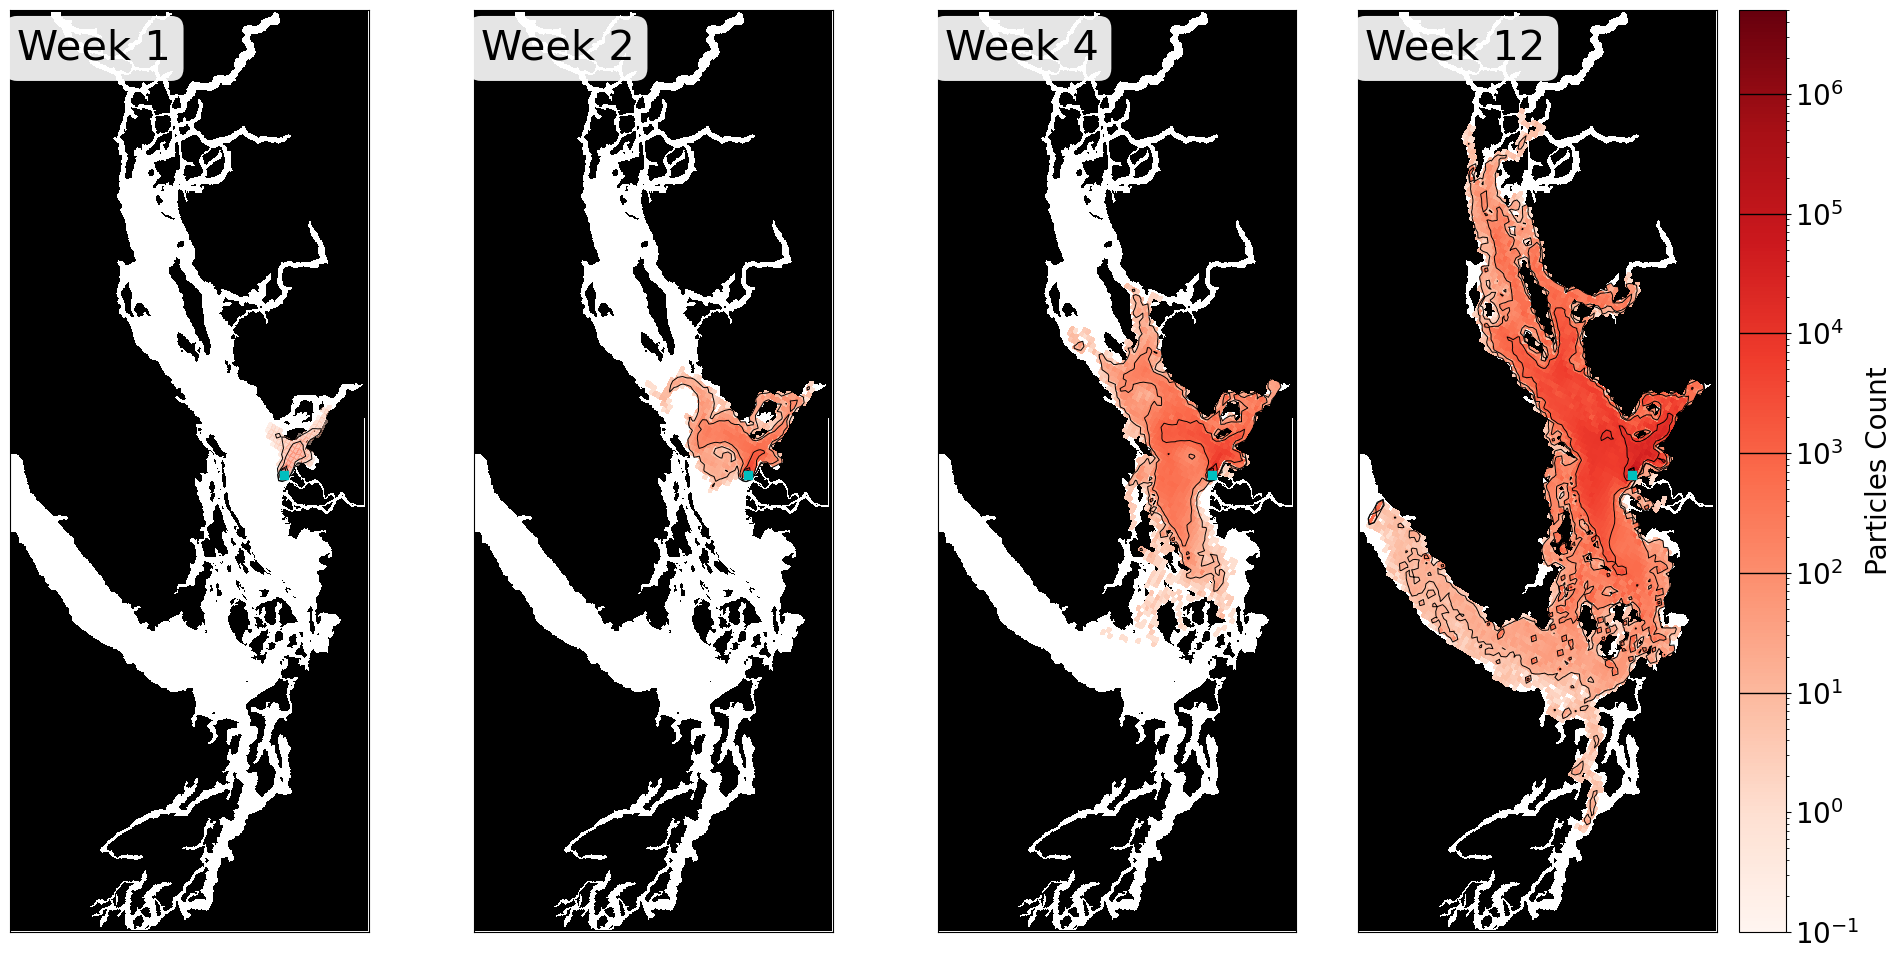

In [155]:
plt.rcParams.update({'font.size': 20})
from matplotlib.colors import ListedColormap, BoundaryNorm
# Colormap for mask
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
x = np.linspace(0,397,398)
y = np.linspace(0,897,898)
X, Y =np.meshgrid(x,y)
#

fig, ax = plt.subplots(1, 4, figsize = (20, 10))
ax[0].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)

caca1 = ax[0].pcolormesh(grid_ij1[0], grid_ij1[1], amount1, 
                         norm=colors.LogNorm(vmin=amount4.min().min() + 1e-1, vmax=amount4.max().max()), cmap = 'Reds',
                         alpha = .5)
ax[0].contour(grid_ij1[0], grid_ij1[1], amount1, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
ax[0].scatter(x_source, y_source, marker = 's', c = 'c', zorder = 3)
#
ax[1].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)
caca2 = ax[1].pcolormesh(grid_ij2[0], grid_ij2[1], amount2, 
                         norm=colors.LogNorm(vmin=amount4.min().min() + 1e-1, vmax=amount4.max().max()), cmap = 'Reds')
ax[1].contour(grid_ij2[0], grid_ij2[1], amount2, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
ax[1].scatter(x_source, y_source, marker = 's', c = 'c', zorder = 3)

#
ax[2].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)
caca3 = ax[2].pcolormesh(grid_ij3[0], grid_ij3[1], amount3, 
                         norm=colors.LogNorm(vmin=amount4.min().min() + 1e-1, vmax=amount4.max().max()), cmap = 'Reds')
ax[2].contour(grid_ij3[0], grid_ij3[1], amount3, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
ax[2].scatter(x_source, y_source, marker = 's', c = 'c', zorder = 3)

#
ax[3].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)
caca4 = ax[3].pcolormesh(grid_ij4[0], grid_ij4[1], amount4, 
                         norm=colors.LogNorm(vmin=amount4.min().min() + 1e-1, vmax=amount4.max().max()), cmap = 'Reds')
ax[3].contour(grid_ij4[0], grid_ij4[1], amount4, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid')
ax[3].scatter(x_source, y_source, marker = 's', c = 'c', zorder = 3)

cb4 = plt.colorbar(caca4, ax = ax[3])
cb4.set_label('Particles Count')
for lev in levels:
    cb4.ax.hlines(
        lev, 
        *cb4.ax.get_xlim(),   # span full width
        colors='black',
        linewidth=1
    )
#
for axis in ax:
    axis.set_aspect(1.14)
    axis.set_xticks([])
    axis.set_yticks([])
#
labels = ['Week 1', 'Week 2', 'Week 4', 'Week 12']

for axis, label in zip(ax, labels):
    axis.text(
        0.02, 0.98,
        label,
        transform=axis.transAxes,
        ha='left',
        va='top',
        fontsize=30,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            boxstyle='round,pad=0.3'
        )
    )

plt.tight_layout()